# Speech Emotion Recognition & Speaker Identification
**ECS7013P Deep Learning for Audio & Music**

This notebook trains two deep learning models on the RAVDESS dataset and then combines them into a multi-task system:

1. **EmotionCNN** — 5-layer 2D CNN for emotion recognition from mel-spectrograms, with mixup augmentation
2. **SpeakerNet** — 1D CNN + BiLSTM + Attention for identifying which speaker is talking
3. **MultiTaskNet** — shared CNN encoder that does both tasks at once, to see if speaker info helps emotion recognition

**Dataset:** RAVDESS — 24 actors performing 4 emotions (neutral, happy, sad, angry), 672 clips total.


In [1]:
import os, sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, '.')
from data_utils import (collect_file_paths, print_dataset_stats, split_by_speaker,
                         prepare_dataloaders, EMOTION_LABELS, waveform_to_mel_spectrogram,
                         load_and_preprocess_audio)
from augment_utils import (SpecAugment, compute_class_weights, mixup_data, mixup_criterion)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

[HAMI-core Msg(1739256:140602669833536:libvgpu.c:839)]: Initializing.....


Device: cuda


[HAMI-core Msg(1739256:140602669833536:libvgpu.c:855)]: Initialized


## 1. Data Loading

Two separate splits because the two tasks have different requirements:
- **Emotion:** speaker-independent (actors 3,4 for validation, 23,24 for test). This way the test checks if the model works on completely new voices.
- **Speaker ID:** random per-speaker split (70/15/15). All 24 speakers need to be in training because you can't identify someone you've never heard.

Total samples: 672

Emotion distribution:
  angry: 192
  happy: 192
  neutral: 96
  sad: 192

Speakers: 24
Speaker-independent split: Train=560 Val=56 Test=56

Emotion: Train=560 Val=56 Test=56
Speaker: Train=456 Val=96 Test=120


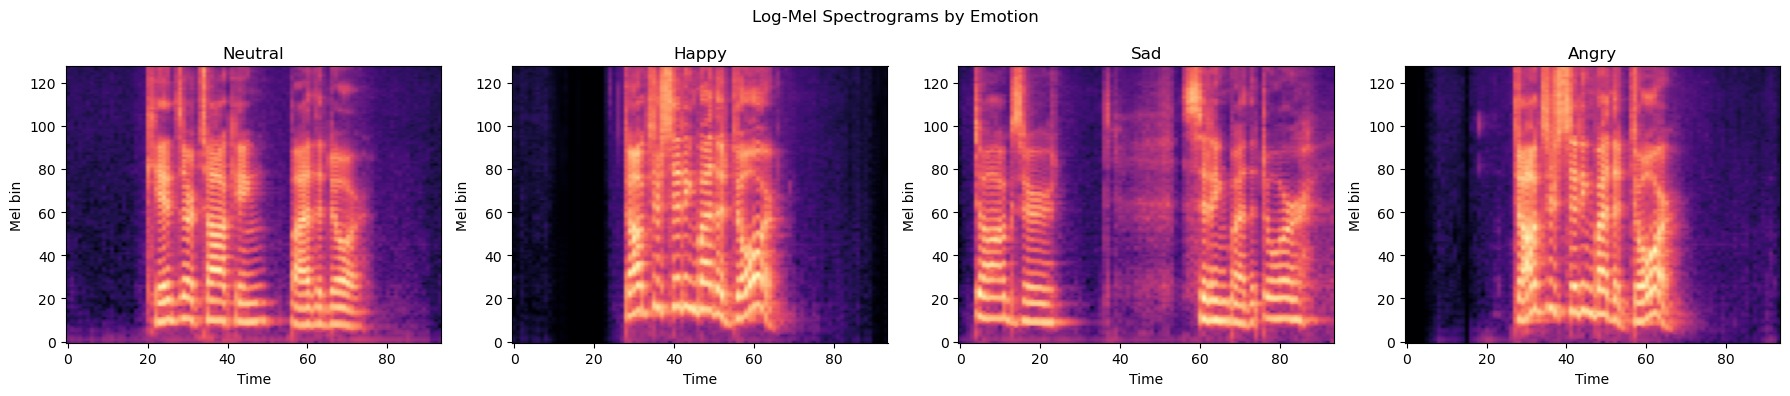

In [2]:
DATA_DIR = 'audio_speech_actors_01-24'
samples = collect_file_paths(DATA_DIR)
print_dataset_stats(samples)

# Emotion: speaker-independent split
train_samples, val_samples, test_samples = split_by_speaker(samples, val_speakers=[3, 4], test_speakers=[23, 24])

# Speaker: random split (all 24 speakers in train)
import random as _rng
_rng.seed(42)
spk_train, spk_val, spk_test = [], [], []
for sid in range(24):
    sf = [s for s in samples if s['speaker'] == sid]
    _rng.shuffle(sf)
    n = len(sf)
    nt, nv = int(n * 0.7), int(n * 0.15)
    spk_train.extend(sf[:nt])
    spk_val.extend(sf[nt:nt+nv])
    spk_test.extend(sf[nt+nv:])

# Dataloaders(128 mel bands)
train_loader, val_loader, test_loader = prepare_dataloaders(
    train_samples, val_samples, test_samples, batch_size=16, n_mels=128)
spk_train_loader, spk_val_loader, spk_test_loader = prepare_dataloaders(
    spk_train, spk_val, spk_test, batch_size=16, n_mels=128)

print(f'\nEmotion: Train={len(train_samples)} Val={len(val_samples)} Test={len(test_samples)}')
print(f'Speaker: Train={len(spk_train)} Val={len(spk_val)} Test={len(spk_test)}')

# Visualise spectrograms
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, name in enumerate(EMOTION_LABELS):
    ex = next(s for s in samples if s['emotion_name'] == name)
    wf = load_and_preprocess_audio(ex['path'])
    ms = waveform_to_mel_spectrogram(wf, n_mels=128)
    axes[i].imshow(ms[0].numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(name.capitalize())
    axes[i].set_xlabel('Time'); axes[i].set_ylabel('Mel bin')
plt.suptitle('Log-Mel Spectrograms by Emotion')
plt.tight_layout(); plt.savefig('spectrograms_by_emotion.png', dpi=150); plt.show()

## 2. Model Definitions

Models are defined in `models.py` to keep this notebook focused on training and evaluation.

- **EmotionCNN**: 5-layer 2D CNN that treats the mel-spectrogram as an image
- **SpeakerNet**: 1D CNN + BiLSTM + Attention that processes the spectrogram as a temporal sequence
- **MultiTaskNet**: shared EmotionCNN encoder with two heads (emotion + speaker)

The two individual models use deliberately different architectures (2D vs 1D+RNN) as required by the brief.

In [3]:
from models import EmotionCNN, SpeakerNet, MultiTaskNet

# quick check that everything loads
print(f'EmotionCNN params:  {sum(p.numel() for p in EmotionCNN().parameters()):,}')
print(f'SpeakerNet params:  {sum(p.numel() for p in SpeakerNet().parameters()):,}')
print(f'MultiTaskNet params: {sum(p.numel() for p in MultiTaskNet().parameters()):,}')

EmotionCNN params:  1,012,804
SpeakerNet params:  778,201
MultiTaskNet params: 1,195,805


## 3. Training Functions


In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device, use_mixup=False):
    # Train one epoch with optional mixup augmentation.
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for mel, emo, spk in loader:
        mel, labels = mel.to(device), emo.to(device)
        optimizer.zero_grad()

        if use_mixup:
            mel_mixed, y_a, y_b, lam = mixup_data(mel, labels, alpha=0.4)
            out = model(mel_mixed)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_a.cpu().numpy())
        else:
            out = model(mel)
            loss = criterion(out, labels)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * mel.size(0)

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device, task='emotion'):
    # Evaluate on val/test. Returns loss, acc, f1, predictions, labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for mel, emo, spk in loader:
            mel = mel.to(device)
            labels = emo.to(device) if task == 'emotion' else spk.to(device)
            out = model(mel)
            loss = criterion(out, labels)
            total_loss += loss.item() * mel.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader.dataset), acc, f1, all_preds, all_labels


def train_one_epoch_speaker(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for mel, emo, spk in loader:
        mel, labels = mel.to(device), spk.to(device)
        optimizer.zero_grad()
        out = model(mel)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * mel.size(0)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


def train_one_epoch_multitask(model, loader, emo_crit, spk_crit,
                               optimizer, device, lam=0.5, use_mixup=False):
    # Multi-task: total_loss = emotion_loss + lambda * speaker_loss.
    model.train()
    total_loss, emo_preds, emo_labels_list = 0, [], []

    for mel, emo, spk in loader:
        mel = mel.to(device)
        emo_labels = emo.to(device)
        spk_labels = spk.to(device)
        optimizer.zero_grad()

        if use_mixup:
            mel_mixed, emo_a, emo_b, lam_mix = mixup_data(mel, emo_labels, alpha=0.4)
            emo_out, spk_out = model(mel_mixed)
            emo_loss = mixup_criterion(emo_crit, emo_out, emo_a, emo_b, lam_mix)
        else:
            emo_out, spk_out = model(mel)
            emo_loss = emo_crit(emo_out, emo_labels)

        spk_loss = spk_crit(spk_out, spk_labels)
        loss = emo_loss + lam * spk_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * mel.size(0)
        emo_preds.extend(emo_out.argmax(1).cpu().numpy())
        emo_labels_list.extend(emo_labels.cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(emo_labels_list, emo_preds)


def evaluate_multitask(model, loader, emo_crit, device):
    # Evaluate combined model only look at emotion accuracy.
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for mel, emo, spk in loader:
            mel, emo_labels = mel.to(device), emo.to(device)
            emo_out, _ = model(mel)
            loss = emo_crit(emo_out, emo_labels)
            total_loss += loss.item() * mel.size(0)
            all_preds.extend(emo_out.argmax(1).cpu().numpy())
            all_labels.extend(emo_labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader.dataset), acc, f1, all_preds, all_labels

print('Training functions ready.')

Training functions ready.


## 4. Model 1 — EmotionCNN

Hyperparameters selected from a grid search over 96 combinations. Best config: dropout=0.1, lr=0.001 with Adam, cosine annealing, and mixup. 

In [5]:
# Best hyperparameters from grid search
emo_dropout = 0.1
emo_lr = 0.001
emo_use_mixup = True
emo_scheduler_type = 'cosine'

class_weights = compute_class_weights(train_samples).to(device)

model = EmotionCNN(num_emotions=4, dropout_rate=emo_dropout, use_specaugment=False).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=emo_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

best_vl, best_state, wait = float('inf'), None, 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

t0 = time.time()
for epoch in range(30):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, use_mixup=emo_use_mixup)
    vl, va, _, _, _ = evaluate(model, val_loader, criterion, device)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta); history['val_acc'].append(va)
    scheduler.step()
    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= 7: break
    print(f'Epoch {epoch+1:2d} | Train Loss: {tl:.4f} Acc: {ta:.1%} | Val Loss: {vl:.4f} Acc: {va:.1%}')

model.load_state_dict(best_state)
_, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, device)
elapsed = time.time() - t0

best_config = {'dropout': emo_dropout, 'lr': emo_lr, 'augment': 'none',
               'scheduler': emo_scheduler_type, 'mixup': emo_use_mixup,
               'test_acc': test_acc, 'test_f1': test_f1, 'epochs': epoch+1,
               'history': history, 'test_preds': preds, 'test_labels': labels}
best_model_state = best_state

print(f'\nEmotionCNN done in {elapsed:.0f}s — Acc: {test_acc:.1%}, F1: {test_f1:.4f}')


Epoch  1 | Train Loss: 1.2583 Acc: 34.1% | Val Loss: 1.2043 Acc: 42.9%
Epoch  2 | Train Loss: 1.2013 Acc: 36.8% | Val Loss: 1.2383 Acc: 41.1%
Epoch  3 | Train Loss: 1.1997 Acc: 42.0% | Val Loss: 1.2692 Acc: 41.1%
Epoch  4 | Train Loss: 1.1513 Acc: 34.5% | Val Loss: 1.1362 Acc: 39.3%
Epoch  5 | Train Loss: 1.1779 Acc: 33.8% | Val Loss: 1.1167 Acc: 39.3%
Epoch  6 | Train Loss: 1.1617 Acc: 36.2% | Val Loss: 1.1837 Acc: 41.1%
Epoch  7 | Train Loss: 1.1411 Acc: 37.1% | Val Loss: 1.1019 Acc: 55.4%
Epoch  8 | Train Loss: 1.1409 Acc: 37.1% | Val Loss: 1.1784 Acc: 42.9%
Epoch  9 | Train Loss: 1.0968 Acc: 40.0% | Val Loss: 1.1407 Acc: 42.9%
Epoch 10 | Train Loss: 1.1178 Acc: 44.8% | Val Loss: 1.1318 Acc: 42.9%
Epoch 11 | Train Loss: 1.1103 Acc: 41.2% | Val Loss: 1.2030 Acc: 42.9%
Epoch 12 | Train Loss: 1.0907 Acc: 43.2% | Val Loss: 1.1821 Acc: 39.3%
Epoch 13 | Train Loss: 1.1149 Acc: 37.3% | Val Loss: 1.1386 Acc: 39.3%
Epoch 14 | Train Loss: 1.1160 Acc: 35.7% | Val Loss: 1.0872 Acc: 50.0%
Epoch 

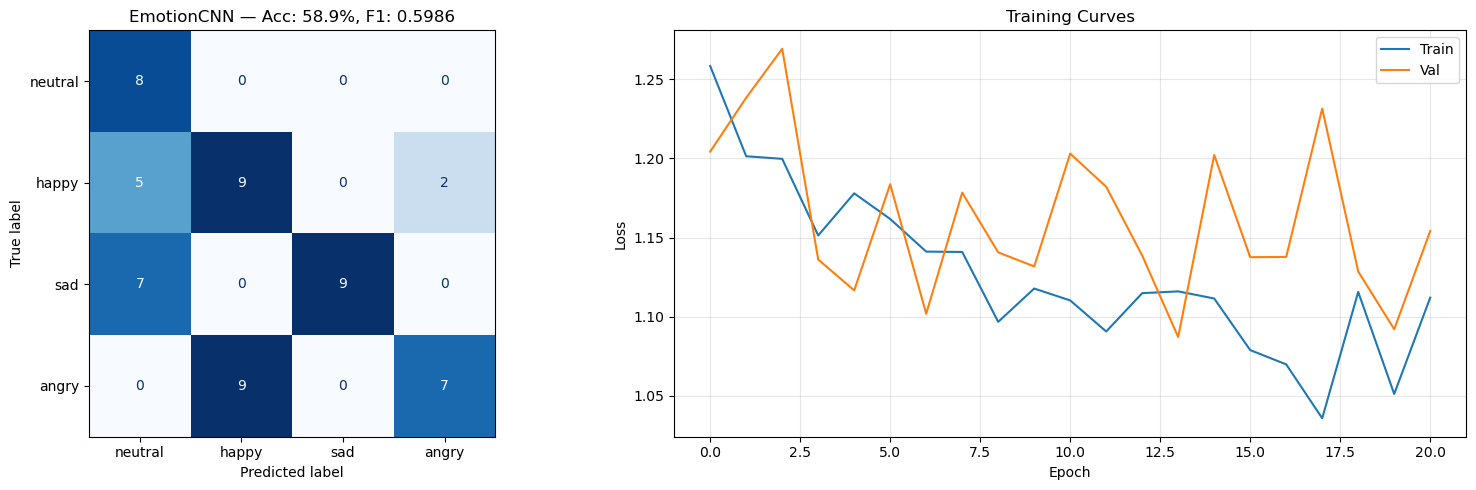

In [6]:
be = best_config

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm = confusion_matrix(be['test_labels'], be['test_preds'])
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'EmotionCNN — Acc: {be["test_acc"]:.1%}, F1: {be["test_f1"]:.4f}')
axes[1].plot(be['history']['train_loss'], label='Train')
axes[1].plot(be['history']['val_loss'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('emotion_cnn_best.png', dpi=150); plt.show()

# To save confusion matrix and training curves as CSV
pd.DataFrame(cm, index=EMOTION_LABELS, columns=EMOTION_LABELS).to_csv('emotion_confusion_matrix.csv')
pd.DataFrame({'epoch': range(1, len(be['history']['train_loss'])+1),
              'train_loss': be['history']['train_loss'],
              'val_loss': be['history']['val_loss']}).to_csv('emotion_training_curves.csv', index=False)

torch.save(best_model_state, 'emotion_cnn_best.pth')
best_emo = {'test_acc': be['test_acc'], 'test_f1': be['test_f1'], 'epochs': be['epochs']}

## 5. Model 2 — SpeakerNet

Hyperparameters from a 16-experiment grid search. Best config was dropout=0.1, lr=0.0003, lstm_hidden=128, single LSTM layer, ReduceLR scheduler.

Uses the random split where all 24 speakers appear in training.

In [7]:
# Best hyperparameters
spk_dropout = 0.1
spk_lr = 0.0003
spk_lstm_hidden = 128
spk_lstm_layers = 1
spk_use_sched = True

model = SpeakerNet(n_mels=128, num_speakers=24, lstm_hidden=spk_lstm_hidden,
                   lstm_layers=spk_lstm_layers, dropout_rate=spk_dropout).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=spk_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

best_vl, best_state, wait = float('inf'), None, 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

t0 = time.time()
for epoch in range(30):
    tl, ta = train_one_epoch_speaker(model, spk_train_loader, criterion, optimizer, device)
    vl, va, _, _, _ = evaluate(model, spk_val_loader, criterion, device, 'speaker')
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta); history['val_acc'].append(va)
    scheduler.step(vl)
    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= 7: break
    print(f'Epoch {epoch+1:2d} | Train Loss: {tl:.4f} Acc: {ta:.1%} | Val Loss: {vl:.4f} Acc: {va:.1%}')

model.load_state_dict(best_state)
_, test_acc, test_f1, preds, labels = evaluate(model, spk_test_loader, criterion, device, 'speaker')
elapsed = time.time() - t0

best_spk_config = {'dropout': spk_dropout, 'lr': spk_lr, 'lstm_hidden': spk_lstm_hidden,
                   'lstm_layers': spk_lstm_layers, 'scheduler': spk_use_sched,
                   'test_acc': test_acc, 'test_f1': test_f1, 'epochs': epoch+1,
                   'history': history, 'test_preds': preds, 'test_labels': labels}
best_spk_state = best_state

print(f'\nSpeakerNet done in {elapsed:.0f}s — Acc: {test_acc:.1%}, F1: {test_f1:.4f}')


Epoch  1 | Train Loss: 3.1686 Acc: 2.4% | Val Loss: 3.1374 Acc: 11.5%
Epoch  2 | Train Loss: 3.0429 Acc: 10.7% | Val Loss: 2.8904 Acc: 13.5%
Epoch  3 | Train Loss: 2.6910 Acc: 16.2% | Val Loss: 2.4854 Acc: 35.4%
Epoch  4 | Train Loss: 2.2998 Acc: 28.1% | Val Loss: 2.2697 Acc: 33.3%
Epoch  5 | Train Loss: 1.9635 Acc: 35.7% | Val Loss: 2.9570 Acc: 18.8%
Epoch  6 | Train Loss: 1.8401 Acc: 43.9% | Val Loss: 1.7722 Acc: 47.9%
Epoch  7 | Train Loss: 1.5779 Acc: 55.0% | Val Loss: 1.6013 Acc: 50.0%
Epoch  8 | Train Loss: 1.3725 Acc: 61.6% | Val Loss: 1.5905 Acc: 42.7%
Epoch  9 | Train Loss: 1.2111 Acc: 63.2% | Val Loss: 1.1067 Acc: 70.8%
Epoch 10 | Train Loss: 1.0637 Acc: 70.0% | Val Loss: 1.2122 Acc: 62.5%
Epoch 11 | Train Loss: 0.9577 Acc: 71.3% | Val Loss: 1.2941 Acc: 58.3%
Epoch 12 | Train Loss: 0.8692 Acc: 76.3% | Val Loss: 1.1561 Acc: 59.4%
Epoch 13 | Train Loss: 0.8223 Acc: 76.1% | Val Loss: 0.8920 Acc: 72.9%
Epoch 14 | Train Loss: 0.7404 Acc: 80.0% | Val Loss: 0.8926 Acc: 71.9%
Epoch 1

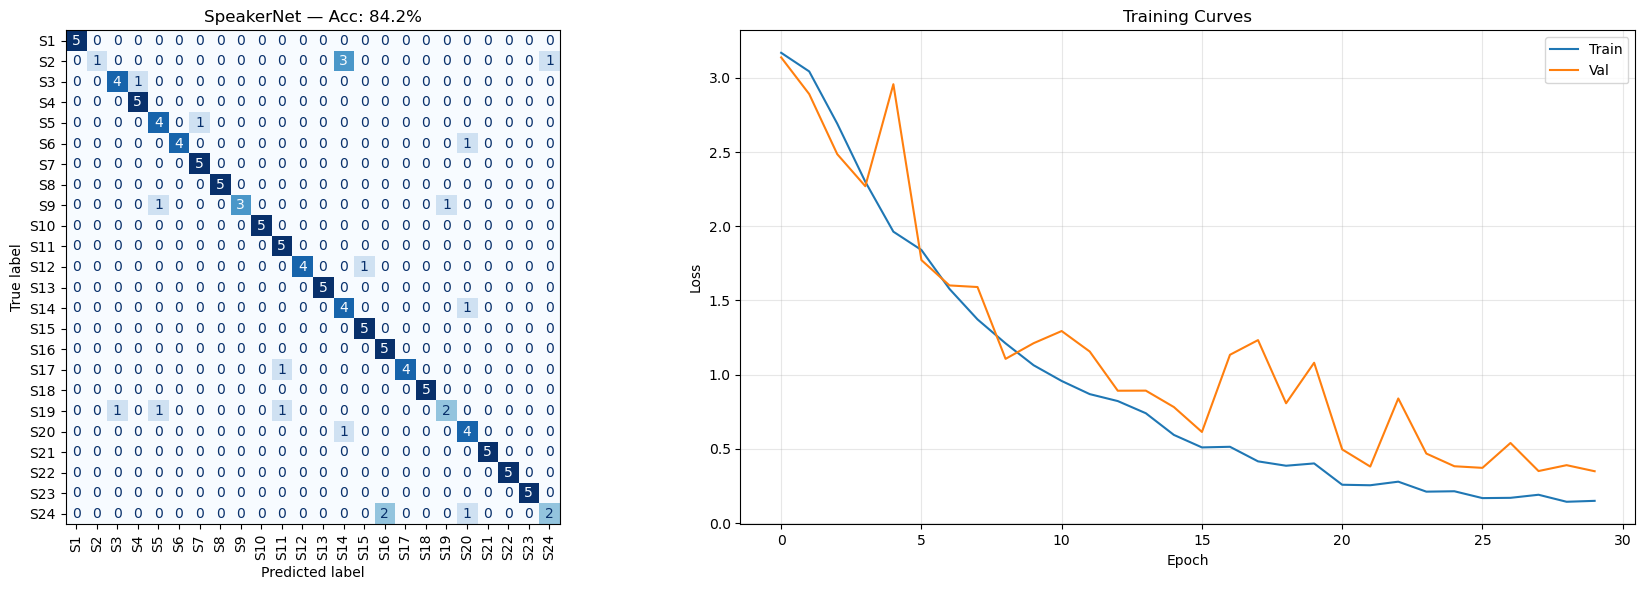

In [8]:
bs = best_spk_config
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cm = confusion_matrix(bs['test_labels'], bs['test_preds'])
ConfusionMatrixDisplay(cm, display_labels=[f'S{i+1}' for i in range(24)]).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=90)
axes[0].set_title(f'SpeakerNet — Acc: {bs["test_acc"]:.1%}')
axes[1].plot(bs['history']['train_loss'], label='Train')
axes[1].plot(bs['history']['val_loss'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('speaker_net_best.png', dpi=150); plt.show()

pd.DataFrame(cm, index=[f'S{i+1}' for i in range(24)],
             columns=[f'S{i+1}' for i in range(24)]).to_csv('speaker_confusion_matrix.csv')
pd.DataFrame({'epoch': range(1, len(bs['history']['train_loss'])+1),
              'train_loss': bs['history']['train_loss'],
              'val_loss': bs['history']['val_loss']}).to_csv('speaker_training_curves.csv', index=False)

torch.save(best_spk_state, 'speaker_net_best.pth')
best_spk = {'test_acc': bs['test_acc'], 'test_f1': bs['test_f1'], 'epochs': bs['epochs']}

## 6. Combined — MultiTaskNet (Lambda Search)

The combined model uses the emotion split so results are directly comparable to Model 1. The speaker head only sees 20 out of 24 speakers (the test ones are held out), but that's fine — the speaker task is just a helper, and at test time I only measure emotion accuracy.

I sweep over different lambda values to find the best balance between the two losses.


In [9]:
mt_train_speakers = sorted(set(s['speaker'] for s in train_samples))
mt_num_speakers = len(mt_train_speakers)
spk_remap = {orig: new for new, orig in enumerate(mt_train_speakers)}
print(f'Speakers in train: {mt_num_speakers}/24')

# Use best config from emotion grid search
mt_dropout = best_config['dropout']
mt_lr = best_config['lr']
mt_use_mixup = best_config.get('mixup', True)
print(f'Using emotion best config: dropout={mt_dropout}, lr={mt_lr}, mixup={mt_use_mixup}')

lambda_values = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
emo_w = compute_class_weights(train_samples).to(device)

mt_csv = 'multitask_results.csv'
with open(mt_csv, 'w') as f:
    f.write('lambda,test_acc,test_f1,epochs,time_sec\n')

mt_results = []

for lam in lambda_values:
    print(f'\n--- Lambda = {lam} ---')
    set_seed(SEED)

    model = MultiTaskNet(num_emotions=4, num_speakers=mt_num_speakers,
                          dropout_rate=mt_dropout).to(device)
    emo_crit = nn.CrossEntropyLoss(weight=emo_w)
    spk_crit = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=mt_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

    # Wrap loader to remap speaker labels
    class RemapLoader:
        def __init__(self, loader, remap):
            self.loader = loader
            self.remap = remap
        def __iter__(self):
            for mel, emo, spk in self.loader:
                spk_new = torch.tensor([self.remap.get(s.item(), -1) for s in spk])
                yield mel, emo, spk_new
        def __len__(self):
            return len(self.loader)
        @property
        def dataset(self):
            return self.loader.dataset

    remap_train = RemapLoader(train_loader, spk_remap)

    best_vl, best_state, wait = float('inf'), None, 0
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(30):
        tl, ta = train_one_epoch_multitask(model, remap_train, emo_crit, spk_crit,
                                            optimizer, device, lam, use_mixup=mt_use_mixup)
        vl, va, _, _, _ = evaluate_multitask(model, val_loader, emo_crit, device)
        train_losses.append(tl); val_losses.append(vl)
        scheduler.step()

        if vl < best_vl:
            best_vl = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}; wait = 0
        else:
            wait += 1
            if wait >= 7: break

        if epoch % 5 == 0:
            print(f'  Epoch {epoch:3d} | Loss: {tl:.4f} | Val Emo: {va:.1%}')

    model.load_state_dict(best_state)
    _, emo_acc, emo_f1, preds, labels = evaluate_multitask(model, test_loader, emo_crit, device)
    elapsed = time.time() - t0

    diff = emo_acc * 100 - best_emo['test_acc'] * 100
    print(f'  Result: {emo_acc:.1%} ({diff:+.1f}% vs single-task) | {epoch+1} epochs')

    with open(mt_csv, 'a') as f:
        f.write(f'{lam},{emo_acc:.4f},{emo_f1:.4f},{epoch+1},{elapsed:.0f}\n')

    mt_results.append({'lambda': lam, 'emo_acc': emo_acc, 'emo_f1': emo_f1,
                       'epochs': epoch+1, 'time': elapsed,
                       'emo_preds': preds, 'emo_labels': labels,
                       'train_losses': train_losses, 'val_losses': val_losses})

# Lambda results CSV
lambda_df = pd.DataFrame([{'lambda': r['lambda'], 'accuracy': round(r['emo_acc']*100, 2),
                            'f1': round(r['emo_f1'], 4)} for r in mt_results])
lambda_df.to_csv('multitask_lambda_results.csv', index=False)
print('\nLambda search results:')
print(lambda_df.to_string(index=False))

Speakers in train: 20/24
Using emotion best config: dropout=0.1, lr=0.001, mixup=True

--- Lambda = 0.0 ---
  Epoch   0 | Loss: 1.2244 | Val Emo: 50.0%
  Epoch   5 | Loss: 1.1199 | Val Emo: 39.3%
  Result: 42.9% (-16.1% vs single-task) | 10 epochs

--- Lambda = 0.1 ---
  Epoch   0 | Loss: 1.5263 | Val Emo: 48.2%
  Epoch   5 | Loss: 1.4172 | Val Emo: 42.9%
  Epoch  10 | Loss: 1.4015 | Val Emo: 42.9%
  Epoch  15 | Loss: 1.3728 | Val Emo: 50.0%
  Epoch  20 | Loss: 1.3757 | Val Emo: 48.2%
  Epoch  25 | Loss: 1.3492 | Val Emo: 51.8%
  Result: 55.4% (-3.6% vs single-task) | 27 epochs

--- Lambda = 0.3 ---
  Epoch   0 | Loss: 2.1237 | Val Emo: 51.8%
  Epoch   5 | Loss: 2.0088 | Val Emo: 41.1%
  Epoch  10 | Loss: 1.9930 | Val Emo: 41.1%
  Result: 53.6% (-5.4% vs single-task) | 16 epochs

--- Lambda = 0.5 ---
  Epoch   0 | Loss: 2.7240 | Val Emo: 51.8%
  Epoch   5 | Loss: 2.6021 | Val Emo: 41.1%
  Result: 41.1% (-17.9% vs single-task) | 10 epochs

--- Lambda = 0.7 ---
  Epoch   0 | Loss: 3.3234

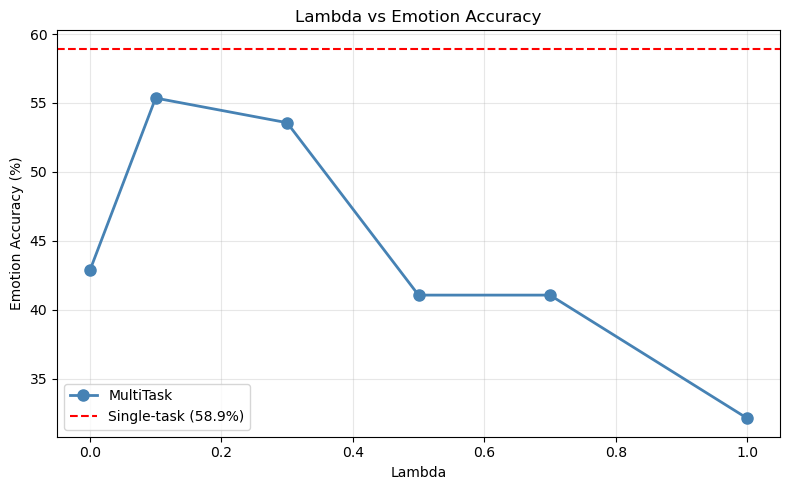

In [10]:
# lambda effect plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['lambda'] for r in mt_results], [r['emo_acc']*100 for r in mt_results],
        'o-', linewidth=2, markersize=8, color='steelblue', label='MultiTask')
ax.axhline(y=best_emo['test_acc']*100, color='red', linestyle='--',
           label=f'Single-task ({best_emo["test_acc"]:.1%})')
ax.set_xlabel('Lambda'); ax.set_ylabel('Emotion Accuracy (%)')
ax.set_title('Lambda vs Emotion Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('multitask_lambda_effect.png', dpi=150); plt.show()

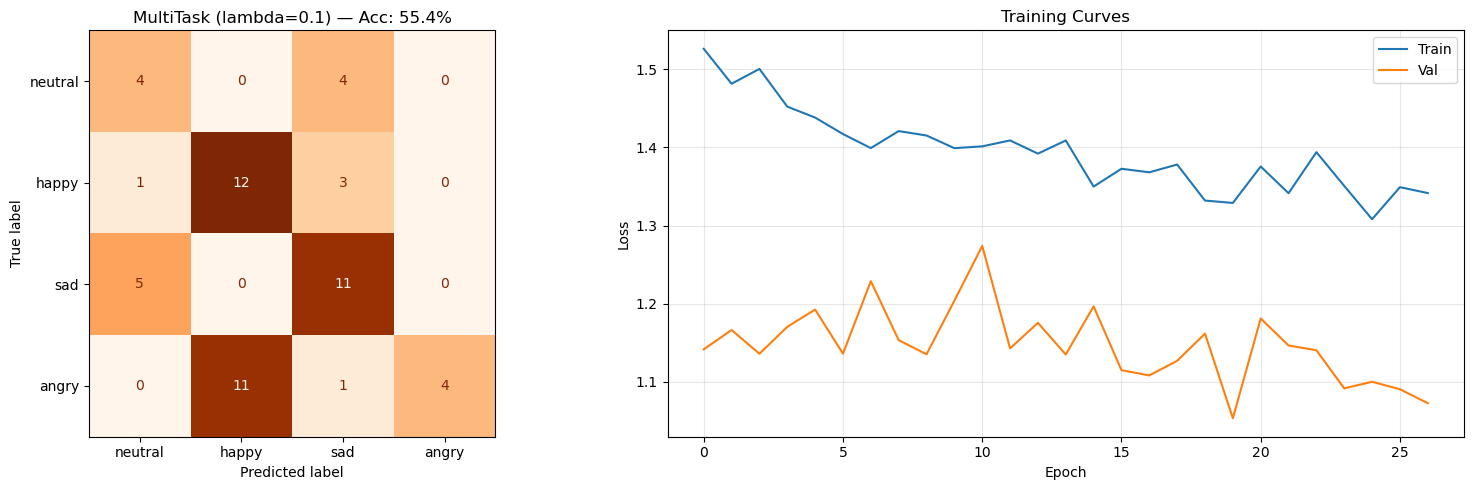

In [11]:
# best combined model
best_mt_idx = max(range(len(mt_results)), key=lambda i: mt_results[i]['emo_acc'])
bm = mt_results[best_mt_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm = confusion_matrix(bm['emo_labels'], bm['emo_preds'])
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title(f'MultiTask (lambda={bm["lambda"]}) — Acc: {bm["emo_acc"]:.1%}')
axes[1].plot(bm['train_losses'], label='Train'); axes[1].plot(bm['val_losses'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('multitask_best.png', dpi=150); plt.show()

## 7. Final Results


In [12]:
print('=' * 60)
print('FINAL RESULTS')
print('=' * 60)
print(f'\n{"Model":<30} {"Acc":>7} {"F1":>7}  Test Set')
print('-' * 60)
print(f'{"EmotionCNN":<30} {best_emo["test_acc"]:6.1%} {best_emo["test_f1"]:.4f}  speaker-independent')
print(f'{"SpeakerNet":<30} {best_spk["test_acc"]:6.1%} {best_spk["test_f1"]:.4f}  random split (closed-set)')
print(f'{"MultiTask (lam=" + str(bm["lambda"]) + ")":<30} {bm["emo_acc"]:6.1%} {bm["emo_f1"]:.4f}  speaker-independent')
print('=' * 60)

results_df = pd.DataFrame([
    {'model': 'EmotionCNN', 'task': 'emotion', 'accuracy': round(best_emo['test_acc']*100, 2),
     'f1_score': round(best_emo['test_f1'], 4), 'test_split': 'speaker-independent'},
    {'model': 'SpeakerNet', 'task': 'speaker', 'accuracy': round(best_spk['test_acc']*100, 2),
     'f1_score': round(best_spk['test_f1'], 4), 'test_split': 'random (closed-set)'},
    {'model': f'MultiTask_lam{bm["lambda"]}', 'task': 'emotion',
     'accuracy': round(bm['emo_acc']*100, 2), 'f1_score': round(bm['emo_f1'], 4),
     'test_split': 'speaker-independent'},
])
results_df.to_csv('final_results.csv', index=False)
print('\nSaved: final_results.csv')
print(results_df.to_string(index=False))

with open('final_summary.txt', 'w') as f:
    f.write(f'Model 1 (EmotionCNN):  Acc={best_emo["test_acc"]:.1%}, F1={best_emo["test_f1"]:.4f}\n')
    f.write(f'Model 2 (SpeakerNet):  Acc={best_spk["test_acc"]:.1%}, F1={best_spk["test_f1"]:.4f}\n')
    f.write(f'Combined (MultiTask):  Acc={bm["emo_acc"]:.1%}, F1={bm["emo_f1"]:.4f}, lambda={bm["lambda"]}\n')
print('Saved: final_summary.txt')

FINAL RESULTS

Model                              Acc      F1  Test Set
------------------------------------------------------------
EmotionCNN                      58.9% 0.5986  speaker-independent
SpeakerNet                      84.2% 0.8314  random split (closed-set)
MultiTask (lam=0.1)             55.4% 0.5332  speaker-independent

Saved: final_results.csv
           model    task  accuracy  f1_score          test_split
      EmotionCNN emotion     58.93    0.5986 speaker-independent
      SpeakerNet speaker     84.17    0.8314 random (closed-set)
MultiTask_lam0.1 emotion     55.36    0.5332 speaker-independent
Saved: final_summary.txt
